In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report

import pickle
import joblib

In [3]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

In [4]:
df = pd.read_csv('fraud_oracle.csv')
print('Dataset shape:', df.shape)

print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

print('\nMissing values before:', df.isnull().sum().sum())
df = df.dropna()
print('Missing values after:', df.isnull().sum().sum())
print('Cleaned shape:', df.shape)

X_raw = df.drop('FraudFound_P', axis=1)
y = df['FraudFound_P']

categorical_cols = X_raw.select_dtypes(include=['object', 'string']).columns
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
print('Features shape after encoding:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Dataset shape: (15420, 33)
Duplicates before: 0
Duplicates after: 0

Missing values before: 0
Missing values after: 0
Cleaned shape: (15420, 33)
Features shape after encoding: (15420, 124)
Train shape: (12336, 124)
Test shape: (3084, 124)


In [5]:
print('Preprocessing complete. Ready for SVM training.')

Preprocessing complete. Ready for SVM training.


In [6]:
base_svm = make_pipeline(StandardScaler(), LinearSVC(C=1.0, random_state=42, max_iter=5000))
base_svm.fit(X_train, y_train)
base_accuracy = base_svm.score(X_test, y_test)
print('Base SVM accuracy:', base_accuracy)

Base SVM accuracy: 0.9400129701686122


Best parameters: {'linearsvc__C': 0.1}
Best accuracy: 0.9400129701686122
Sample predictions: [0 0 0 0 0 0 0 0 0 0]
Confusion matrix:
 [[2899    0]
 [ 185    0]]


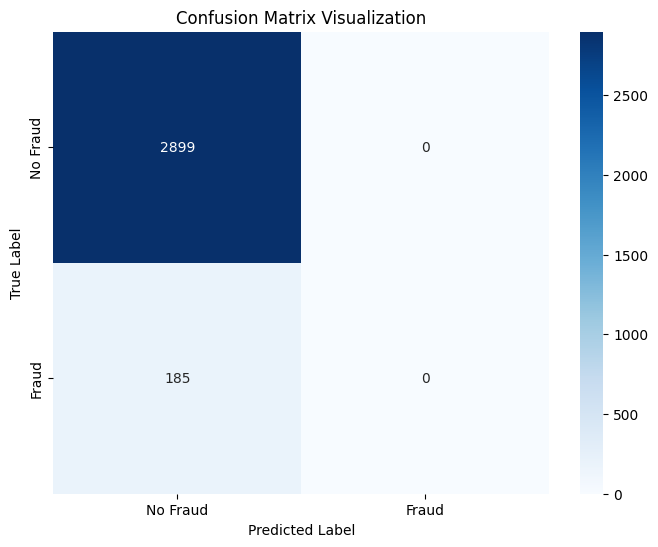

In [10]:
svm_pipeline = make_pipeline(StandardScaler(), LinearSVC(random_state=42, max_iter=5000))
param_grid = {
    'linearsvc__C': [0.1, 1, 5]
}

grid_search = GridSearchCV(svm_pipeline, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_accuracy = best_model.score(X_test, y_test)
best_params = grid_search.best_params_

print('Best parameters:', best_params)
print('Best accuracy:', best_accuracy)

y_pred = best_model.predict(X_test)
print('Sample predictions:', y_pred[:10])

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization')
plt.show()

In [12]:
print('Final model accuracy:', best_accuracy)
print('\nClassification report:\n', classification_report(y_test, y_pred, zero_division=0))


with open('riskproof_svm.pkl', 'wb') as f:
    pickle.dump(best_model, f)

joblib.dump(best_model, 'riskproof_svm.joblib')
print('Saved model files: riskproof_svm.pkl and riskproof_svm.joblib')

Final model accuracy: 0.9400129701686122

Classification report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084

Saved model files: riskproof_svm.pkl and riskproof_svm.joblib
